In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv
/kaggle/input/datasets/mohankrishnathalla/predicting-irrigation-need-submission-dataset/Orginal.csv


## What Is This Competition?

**Competition Goal:** Given agricultural and environmental features, **predict the irrigation need level** for a crop field: **Low**, **Medium**, or **High**.

**Scoring metric:** **Balanced Accuracy** - the average recall per class. Designed for imbalanced datasets.
If your model predicts only "Low", it scores badly because it misses the rare **High** class completely.

**Real-world impact:** Agriculture uses ~70% of global freshwater. Smart irrigation prediction enables precision farming that saves water and maximises crop yield.

> **Key Challenge:** The `High` class is only ~3% of the data. All models must explicitly handle this imbalance.

## Feature Dictionary

| Feature | Meaning | Type | Notes |
|---|---|---|---|
| `Soil_Type` | Sandy / Loamy / Clay / Silt | Categorical (4) | Water retention varies |
| `Soil_pH` | Acidity 4.8-8.2 | Numeric | Affects nutrient availability |
| `Soil_Moisture` | Current moisture % (8-65) | Numeric | Direct water indicator |
| `Organic_Carbon` | Organic matter 0.3-1.6 | Numeric | Improves water retention |
| `Electrical_Conductivity` | Soil salinity 0.1-3.5 | Numeric | High = salt stress |
| `Temperature_C` | Ambient temp 12-42C | Numeric | Drives evapotranspiration |
| `Humidity` | Relative humidity 25-95% | Numeric | High = less irrigation needed |
| `Rainfall_mm` | Recent rainfall 0-2500 mm | Numeric | Natural water supply |
| `Sunlight_Hours` | Daily sun 4-11 hrs | Numeric | Drives crop water demand |
| `Wind_Speed_kmh` | Wind 0.5-20 km/h | Numeric | Increases evaporation |
| `Crop_Type` | Rice/Wheat/Maize/Cotton/Sugarcane/Soybean | Categorical (6) | Different water needs |
| `Crop_Growth_Stage` | Sowing/Vegetative/Flowering/Harvest | Categorical (4) | Stage determines need |
| `Season` | Rabi/Kharif/Zaid | Categorical (3) | Indian cropping seasons |
| `Irrigation_Type` | Drip/Sprinkler/Canal/Rainfed | Categorical (4) | Current method |
| `Water_Source` | River/Reservoir/Groundwater/Rainwater | Categorical (4) | Water availability |
| `Field_Area_hectare` | Field size 0.3-15 ha | Numeric | Scale of irrigation |
| `Mulching_Used` | Yes/No | Binary | Reduces evaporation |
| `Previous_Irrigation_mm` | Last irrigation 0-120 mm | Numeric | Recent history |
| `Region` | North/South/East/West/Central | Categorical (5) | Climate zone |
| `Irrigation_Need` | **TARGET** Low/Medium/High | 3-class | |

## Models We Will Try

| Model | Why Include It |
|---|---|
| Logistic Regression | Interpretable baseline; linear class boundaries |
| Decision Tree | Visualisable splits; shows which features matter most |
| Random Forest | Robust ensemble; handles imbalance with class_weight |
| XGBoost | Gradient boosting; regularised; excellent on tabular |
| **LightGBM** | Fastest boosting; native imbalance handling; usually wins |

All models use `class_weight='balanced'` to handle the 3% High class.

# 1. Libraries & Data Loading

In [2]:
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'Low': '#4E79A7', 'Medium': '#F28E2B', 'High': '#E15759'}

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb_lib

print("All libraries loaded!")
for dirpath, _, fnames in os.walk('/kaggle/input'):
    for f in fnames:
        print(os.path.join(dirpath, f))

All libraries loaded!
/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv
/kaggle/input/datasets/mohankrishnathalla/predicting-irrigation-need-submission-dataset/Orginal.csv


In [3]:
COMP      = '/kaggle/input/competitions/playground-series-s6e4'
ORIG_PATH = '/kaggle/input/datasets/mohankrishnathalla/predicting-irrigation-need-submission-dataset/Orginal.csv'

train = pd.read_csv(f'{COMP}/train.csv', index_col='id')
test  = pd.read_csv(f'{COMP}/test.csv',  index_col='id')
sub   = pd.read_csv(f'{COMP}/sample_submission.csv')

# Load original dataset
try:
    orig_df = pd.read_csv(ORIG_PATH)
    if 'id' in orig_df.columns:
        orig_df = orig_df.drop(columns=['id'])
    ORIG_AVAIL = True
    print(f"Original dataset loaded: {orig_df.shape}")
    print(f"  Class dist (original): {orig_df['Irrigation_Need'].value_counts(normalize=True).round(3).to_dict()}")
except Exception as e:
    orig_df = None
    ORIG_AVAIL = False
    print(f"Original not found: {e}")

TARGET   = 'Irrigation_Need'
NUM_COLS = ['Soil_pH','Soil_Moisture','Organic_Carbon','Electrical_Conductivity',
            'Temperature_C','Humidity','Rainfall_mm','Sunlight_Hours',
            'Wind_Speed_kmh','Field_Area_hectare','Previous_Irrigation_mm']
CAT_COLS = ['Soil_Type','Crop_Type','Crop_Growth_Stage','Season',
            'Irrigation_Type','Water_Source','Mulching_Used','Region']

LABEL_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
INV_MAP   = {0: 'Low', 1: 'Medium', 2: 'High'}

# Combine original + synthetic for training (original adds 10k diverse rows)
if ORIG_AVAIL:
    orig_train = orig_df[NUM_COLS + CAT_COLS + [TARGET]].copy()
    train_all  = pd.concat([train, orig_train], ignore_index=True)
    print(f"\nTrain (synthetic only): {train.shape}")
    print(f"Train (+ original):     {train_all.shape}")
else:
    train_all = train.copy()

print(f"\nClass distribution (combined):")
print((train_all[TARGET].value_counts(normalize=True)*100).round(2))

Original dataset loaded: (10000, 20)
  Class dist (original): {'Low': 0.586, 'Medium': 0.38, 'High': 0.034}

Train (synthetic only): (630000, 20)
Train (+ original):     (640000, 20)

Class distribution (combined):
Irrigation_Need
Low       58.72
Medium    37.95
High       3.34
Name: proportion, dtype: float64


## 2.0 Original vs Synthetic Dataset Comparison

The original dataset (10,000 rows) has **some data drift** from the synthetic train (630,000 rows).
Adversarial CV shows highest drift in `Rainfall_mm` (0.636) and `Previous_Irrigation_mm` (0.582).
We include original rows in training for diversity - they act like a weak regularizer for the minority High class.

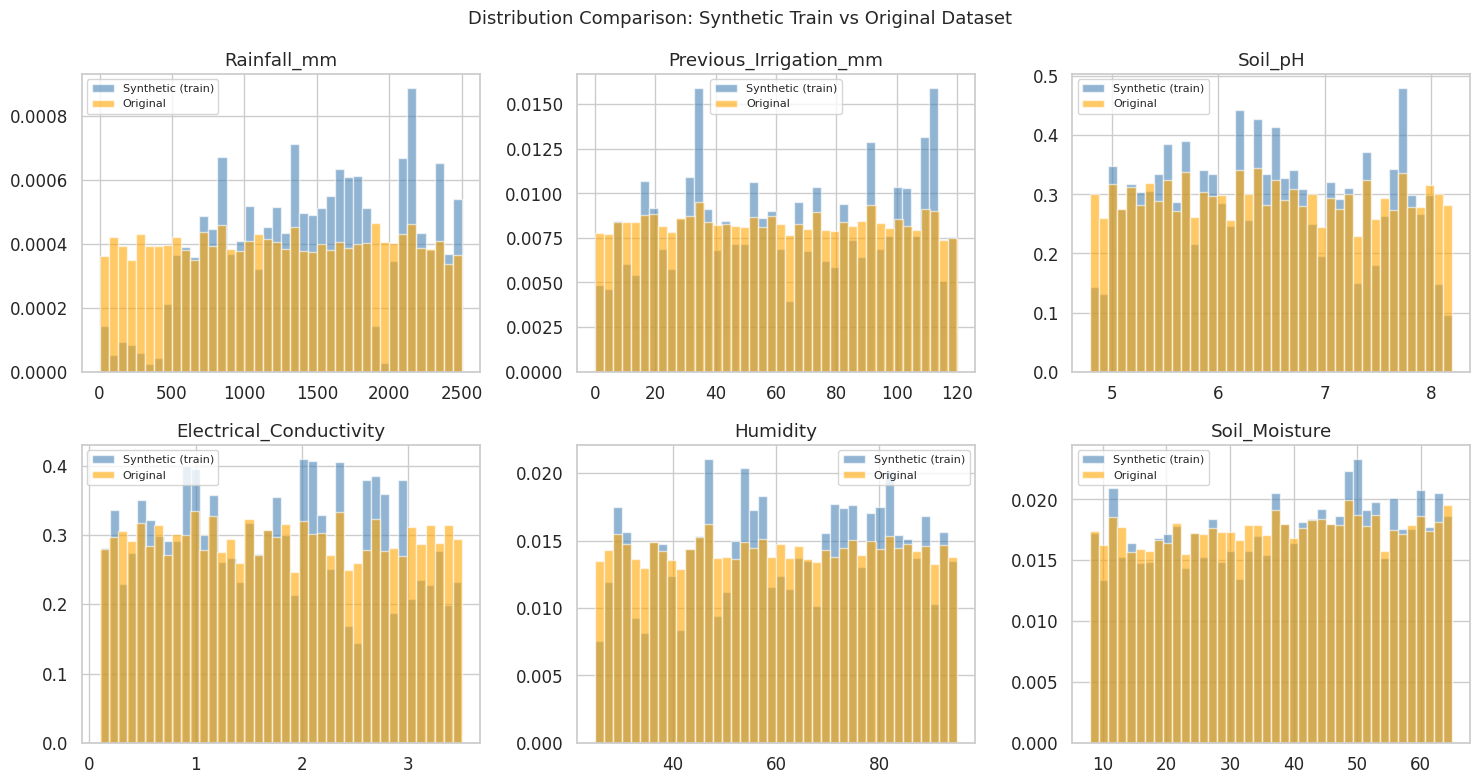

Drift is most visible in Rainfall_mm - original has different range/shape


In [4]:
if ORIG_AVAIL:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    drift_cols = ['Rainfall_mm','Previous_Irrigation_mm','Soil_pH',
                  'Electrical_Conductivity','Humidity','Soil_Moisture']
    for i, col in enumerate(drift_cols):
        axes[i].hist(train[col].sample(5000), bins=40, alpha=0.6,
                     label='Synthetic (train)', color='steelblue', density=True)
        axes[i].hist(orig_df[col], bins=40, alpha=0.6,
                     label='Original', color='orange', density=True)
        axes[i].set_title(col)
        axes[i].legend(fontsize=8)
    plt.suptitle('Distribution Comparison: Synthetic Train vs Original Dataset', fontsize=13)
    plt.tight_layout()
    plt.show()
    print("Drift is most visible in Rainfall_mm - original has different range/shape")
else:
    print("Original dataset not loaded - skipping comparison")

# 2. Exploratory Data Analysis

## 2.1 Class Distribution - The Imbalance Problem

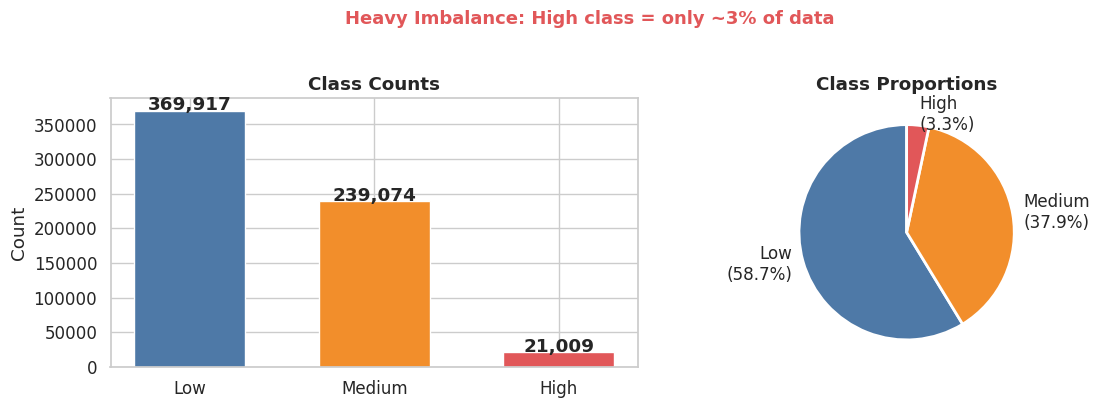

Balanced Accuracy penalises models that ignore the minority class.
Without class weighting, a model predicting only 'Low' would score ~0.33


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order  = ['Low', 'Medium', 'High']
counts = train[TARGET].value_counts()[order]
pcts   = train[TARGET].value_counts(normalize=True)[order] * 100

axes[0].bar(order, counts, color=[PALETTE[c] for c in order], edgecolor='white', width=0.6)
axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(zip(order, counts)):
    axes[0].text(i, cnt + 800, f'{cnt:,}', ha='center', fontweight='bold')

axes[1].pie(pcts, labels=[f'{c}\n({p:.1f}%)' for c,p in zip(order,pcts)],
            colors=[PALETTE[c] for c in order], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle('Heavy Imbalance: High class = only ~3% of data',
             fontsize=13, fontweight='bold', color='#E15759', y=1.02)
plt.tight_layout()
plt.show()
print("Balanced Accuracy penalises models that ignore the minority class.")
print("Without class weighting, a model predicting only 'Low' would score ~0.33")

## 2.2 Numeric Feature Distributions by Class

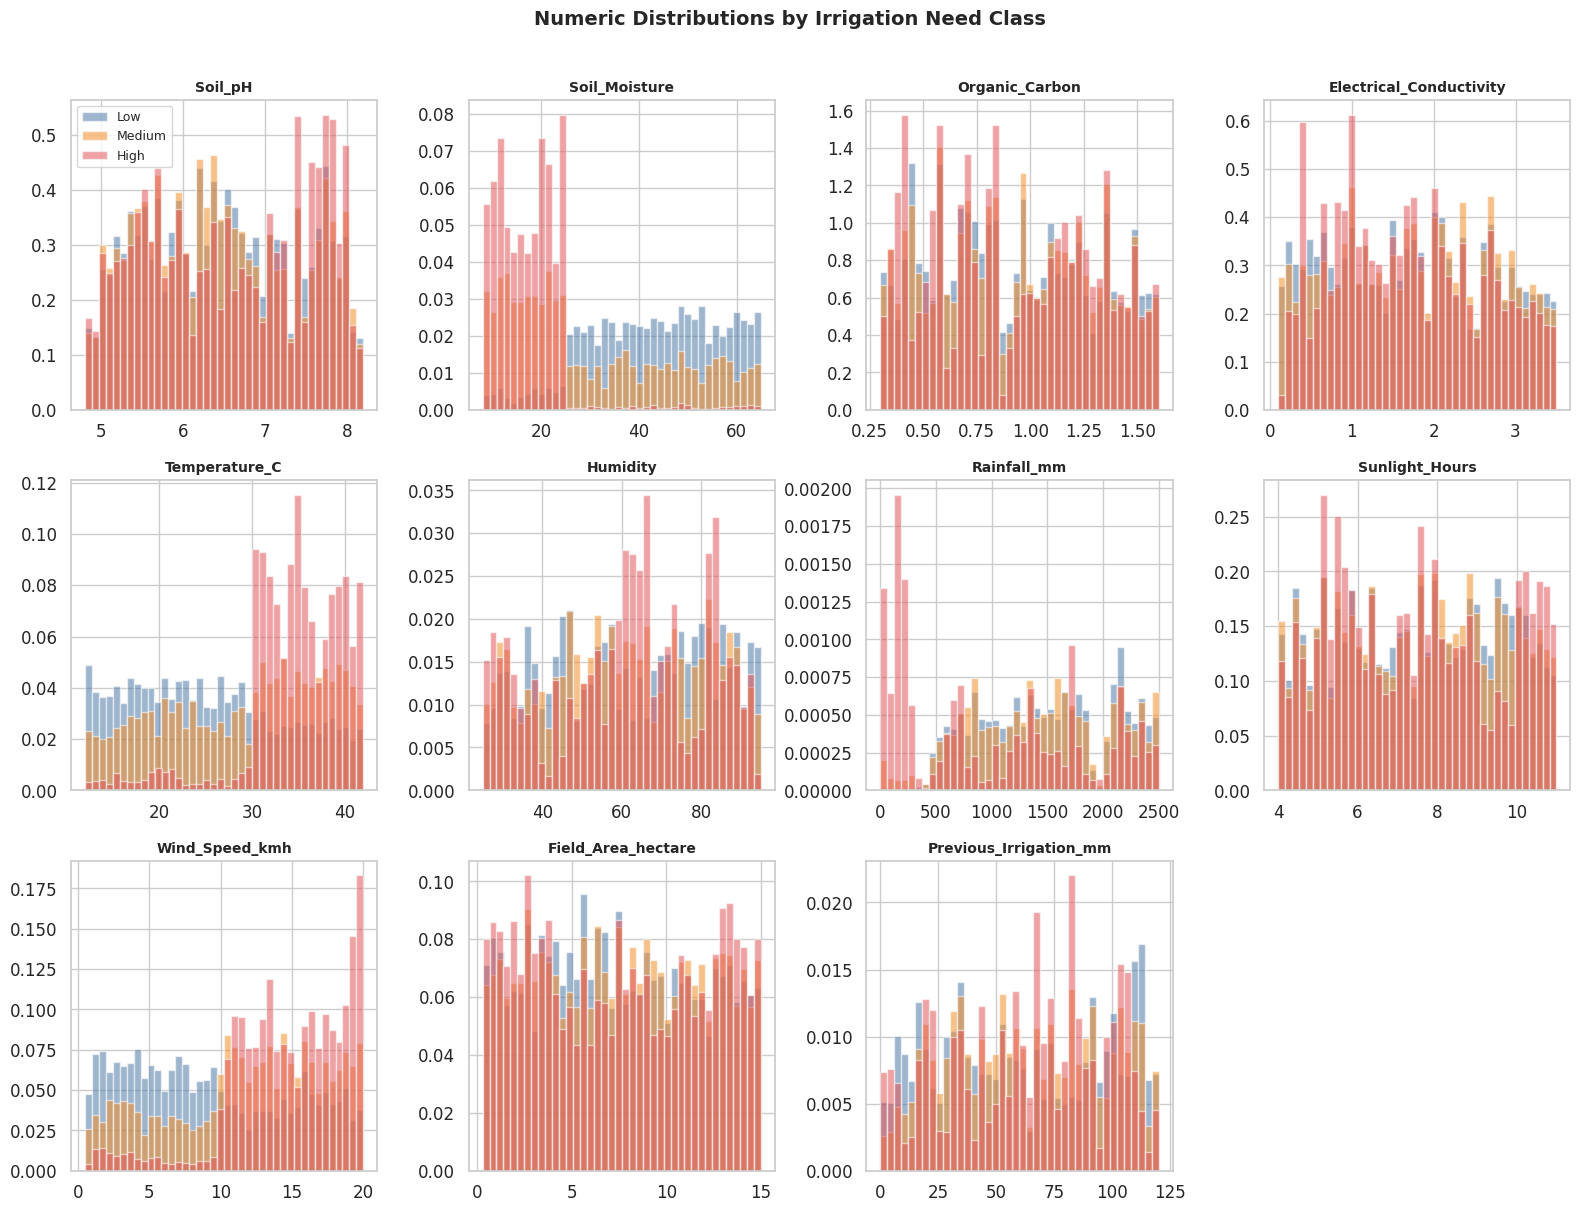

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    for cls in ['Low', 'Medium', 'High']:
        data = train[train[TARGET] == cls][col]
        axes[i].hist(data, bins=40, alpha=0.55, label=cls,
                     color=PALETTE[cls], density=True)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    if i == 0:
        axes[i].legend(fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Numeric Distributions by Irrigation Need Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.3 Categorical Features vs Target

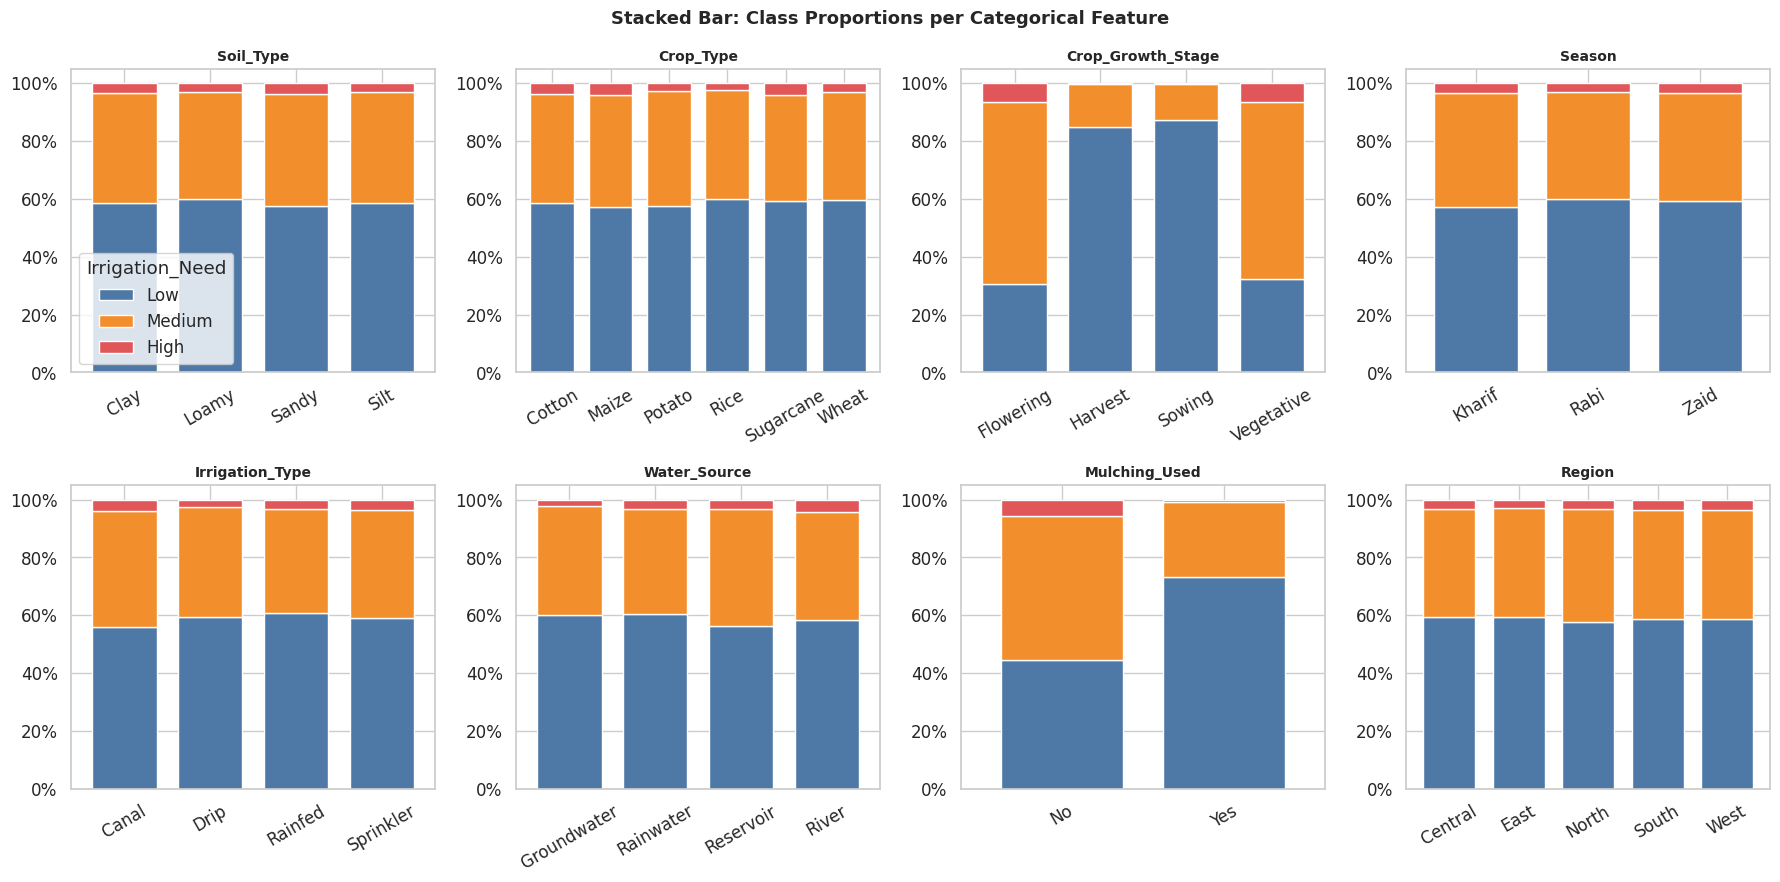

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(train[col], train[TARGET], normalize='index')[['Low','Medium','High']]*100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=[PALETTE['Low'], PALETTE['Medium'], PALETTE['High']],
            edgecolor='white', width=0.75, legend=(i==0))
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.suptitle('Stacked Bar: Class Proportions per Categorical Feature',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.4 Key Features vs Target (Boxplots)

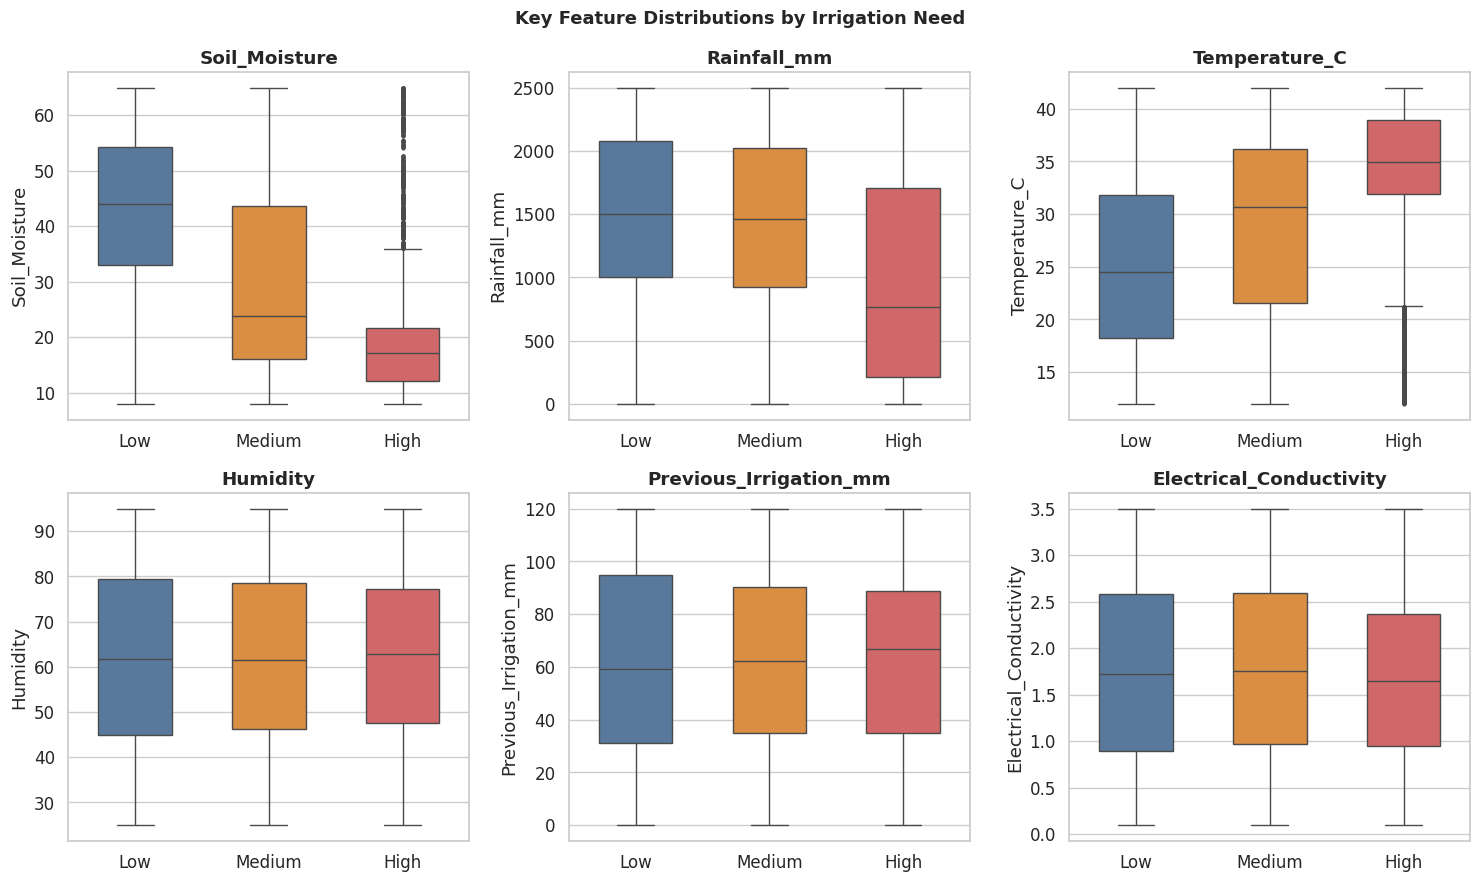

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
key_feats = ['Soil_Moisture','Rainfall_mm','Temperature_C',
             'Humidity','Previous_Irrigation_mm','Electrical_Conductivity']
for i, col in enumerate(key_feats):
    sns.boxplot(data=train[[col,TARGET]], x=TARGET, y=col,
                order=['Low','Medium','High'], palette=PALETTE,
                ax=axes[i], width=0.55, fliersize=2)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Key Feature Distributions by Irrigation Need', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Correlation Heatmap

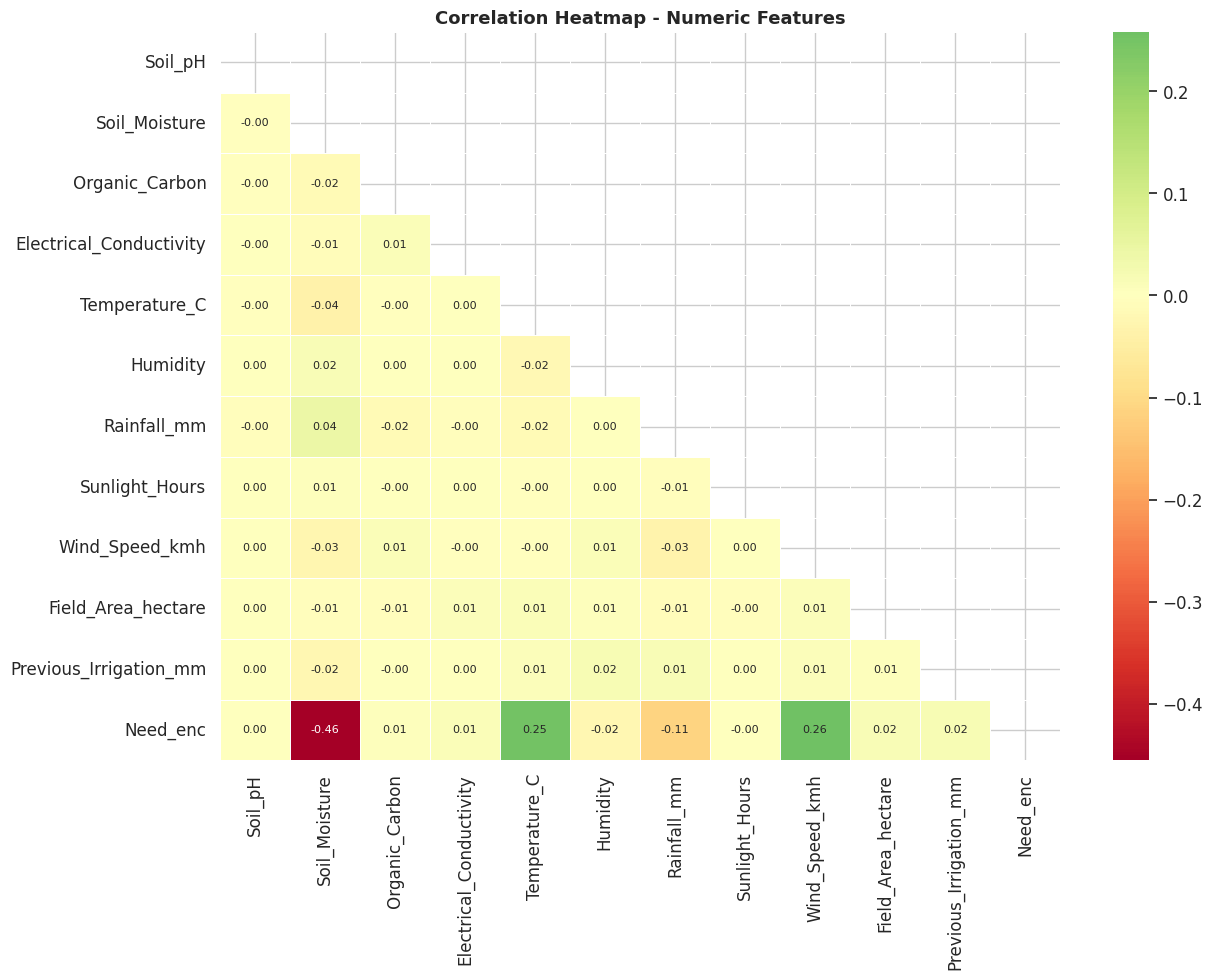

Top correlations with Irrigation_Need:
Soil_Moisture              0.455482
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Rainfall_mm                0.111478
Humidity                   0.021870
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
Sunlight_Hours             0.000313
Soil_pH                    0.000150


In [9]:
corr_df = train[NUM_COLS].copy()
corr_df['Need_enc'] = train[TARGET].map(LABEL_MAP)
corr = corr_df.corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Heatmap - Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top correlations with Irrigation_Need:")
tgt_c = corr['Need_enc'].drop('Need_enc').abs().sort_values(ascending=False)
print(tgt_c.to_string())

# 3. Preprocessing

In [10]:
y = train_all[TARGET].map(LABEL_MAP).values
X = train_all.drop(columns=[TARGET]).copy()
X_tst = test.copy()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[CAT_COLS]     = enc.fit_transform(X[CAT_COLS])
X_tst[CAT_COLS] = enc.transform(X_tst[CAT_COLS])

cw  = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y)
print(f"Class weights: Low={cw[0]:.3f}  Medium={cw[1]:.3f}  High={cw[2]:.3f}")
print(f"High class gets {cw[2]:.1f}x more weight -- essential for balanced accuracy!")

scaler   = StandardScaler()
X_sc     = X.copy()
X_tst_sc = X_tst.copy()
X_sc[NUM_COLS]     = scaler.fit_transform(X[NUM_COLS])
X_tst_sc[NUM_COLS] = scaler.transform(X_tst[NUM_COLS])

FEAT = NUM_COLS + CAT_COLS
print(f"Features: {len(FEAT)}  |  Train: {X.shape}  |  Test: {X_tst.shape}")
print(f"Note: Training includes original dataset rows for diversity!")

Class weights: Low=0.568  Medium=0.878  High=9.995
High class gets 10.0x more weight -- essential for balanced accuracy!
Features: 19  |  Train: (640000, 19)  |  Test: (270000, 19)
Note: Training includes original dataset rows for diversity!


# 4. Model Training - 5-Fold Stratified CV

In [11]:
SKF    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = {}

def cv_train(model, Xdata, ydata, name, sample_weight_fn=None):
    fold_scores = []
    for fold, (tri, vai) in enumerate(SKF.split(Xdata, ydata)):
        Xtr, Xva = Xdata.iloc[tri], Xdata.iloc[vai]
        ytr, yva = ydata[tri], ydata[vai]
        sw = sample_weight_fn(ytr) if sample_weight_fn else None
        if sw is not None:
            model.fit(Xtr, ytr, sample_weight=sw)
        else:
            model.fit(Xtr, ytr)
        s = balanced_accuracy_score(yva, model.predict(Xva))
        fold_scores.append(s)
        print(f"  Fold {fold+1}: {s:.5f}")
    cv_mean = np.mean(fold_scores)
    print(f"  {name}: CV = {cv_mean:.5f} +/- {np.std(fold_scores):.5f}")
    scores[name] = fold_scores
    return cv_mean

## 4.1 Logistic Regression

In [12]:
print("Logistic Regression")
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                        multi_class='multinomial', solver='lbfgs',
                        random_state=42, n_jobs=-1)
lr_cv = cv_train(lr, X_sc[FEAT], y, 'Logistic Regression')

Logistic Regression
  Fold 1: 0.73669
  Fold 2: 0.73172
  Fold 3: 0.73398
  Fold 4: 0.73702
  Fold 5: 0.73249
  Logistic Regression: CV = 0.73438 +/- 0.00215


## 4.2 Decision Tree

In [13]:
print("Decision Tree")
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                            class_weight='balanced', random_state=42)
dt_cv = cv_train(dt, X[FEAT], y, 'Decision Tree')

Decision Tree
  Fold 1: 0.96736
  Fold 2: 0.96681
  Fold 3: 0.96495
  Fold 4: 0.96668
  Fold 5: 0.96371
  Decision Tree: CV = 0.96590 +/- 0.00136


## 4.3 Random Forest

In [14]:
print("Random Forest")
rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                            min_samples_leaf=20, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf_cv = cv_train(rf, X[FEAT], y, 'Random Forest')

Random Forest
  Fold 1: 0.96531
  Fold 2: 0.96664
  Fold 3: 0.96510
  Fold 4: 0.96622
  Fold 5: 0.96165
  Random Forest: CV = 0.96498 +/- 0.00176


## 4.4 XGBoost

In [15]:
print("XGBoost")
fold_scores_xgb = []
xgb = XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
                    colsample_bytree=0.8, subsample=0.8, min_child_weight=5,
                    objective='multi:softprob', num_class=3,
                    eval_metric='mlogloss', tree_method='hist', device='cuda',
                    random_state=42, verbosity=0)
for fold, (tri, vai) in enumerate(SKF.split(X[FEAT], y)):
    Xtr, Xva = X[FEAT].iloc[tri], X[FEAT].iloc[vai]
    ytr, yva = y[tri], y[vai]
    sw = compute_sample_weight('balanced', ytr)
    xgb.fit(Xtr, ytr, sample_weight=sw, eval_set=[(Xva, yva)], verbose=False)
    s = balanced_accuracy_score(yva, xgb.predict(Xva))
    fold_scores_xgb.append(s)
    print(f"  Fold {fold+1}: {s:.5f}")
xgb_cv = np.mean(fold_scores_xgb)
scores['XGBoost'] = fold_scores_xgb
print(f"  XGBoost: CV = {xgb_cv:.5f} +/- {np.std(fold_scores_xgb):.5f}")

XGBoost
  Fold 1: 0.97039
  Fold 2: 0.97010
  Fold 3: 0.97148
  Fold 4: 0.97130
  Fold 5: 0.96710
  XGBoost: CV = 0.97007 +/- 0.00158


## 4.5 LightGBM

In [16]:
print("LightGBM")
fold_scores_lgb = []
lgbm = LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
                      colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
                      objective='multiclass', num_class=3, is_unbalance=True,
                      device='gpu', random_state=42, verbose=-1)
for fold, (tri, vai) in enumerate(SKF.split(X[FEAT], y)):
    Xtr, Xva = X[FEAT].iloc[tri], X[FEAT].iloc[vai]
    ytr, yva = y[tri], y[vai]
    lgbm.fit(Xtr, ytr, eval_set=[(Xva, yva)],
             callbacks=[lgb_lib.early_stopping(50, verbose=False),
                        lgb_lib.log_evaluation(-1)])
    s = balanced_accuracy_score(yva, lgbm.predict(Xva))
    fold_scores_lgb.append(s)
    print(f"  Fold {fold+1}: {s:.5f}")
lgbm_cv = np.mean(fold_scores_lgb)
scores['LightGBM'] = fold_scores_lgb
print(f"  LightGBM: CV = {lgbm_cv:.5f} +/- {np.std(fold_scores_lgb):.5f}")

LightGBM


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  Fold 1: 0.96347
  Fold 2: 0.96364
  Fold 3: 0.96226
  Fold 4: 0.96258
  Fold 5: 0.95734
  LightGBM: CV = 0.96186 +/- 0.00232


# 5. Model Comparison

  MODEL                     MEAN CV     STD      MIN      MAX
  XGBoost                   0.97007 0.00158  0.96710  0.97148 [1st]
  Decision Tree             0.96590 0.00136  0.96371  0.96736 [2nd]
  Random Forest             0.96498 0.00176  0.96165  0.96664
  LightGBM                  0.96186 0.00232  0.95734  0.96364
  Logistic Regression       0.73438 0.00215  0.73172  0.73702


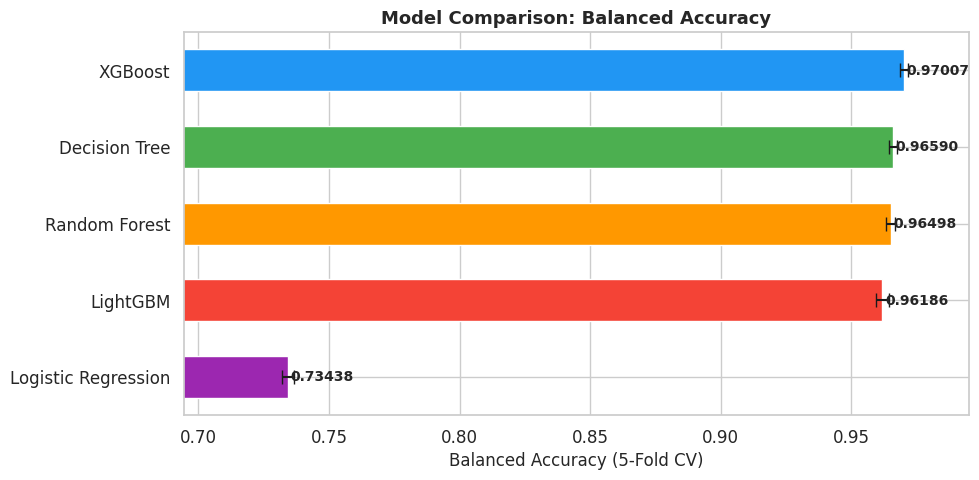

In [17]:
results = pd.DataFrame({
    m: {'Mean': np.mean(f), 'Std': np.std(f),
        'Min': np.min(f), 'Max': np.max(f)}
    for m, f in scores.items()
}).T.sort_values('Mean', ascending=False)

print("=" * 62)
print(f"  {'MODEL':<22} {'MEAN CV':>10} {'STD':>7} {'MIN':>8} {'MAX':>8}")
print("=" * 62)
medals = ['', '']
for i, (model, row) in enumerate(results.iterrows()):
    m = ' [1st]' if i==0 else (' [2nd]' if i==1 else '')
    print(f"  {model:<22} {row['Mean']:>10.5f} {row['Std']:>7.5f} "
          f"{row['Min']:>8.5f} {row['Max']:>8.5f}{m}")
print("=" * 62)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
ax.barh(results.index, results['Mean'], xerr=results['Std'], capsize=5,
        color=colors[:len(results)], edgecolor='white', height=0.55)
ax.set_xlabel('Balanced Accuracy (5-Fold CV)', fontsize=12)
ax.set_title('Model Comparison: Balanced Accuracy', fontsize=13, fontweight='bold')
for i, (m, v) in enumerate(zip(results.index, results['Mean'])):
    ax.text(v + 0.001, i, f'{v:.5f}', va='center', fontweight='bold', fontsize=10)
ax.set_xlim(results['Mean'].min() - 0.04, results['Mean'].max() + 0.025)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 6. Feature Importance (LightGBM)

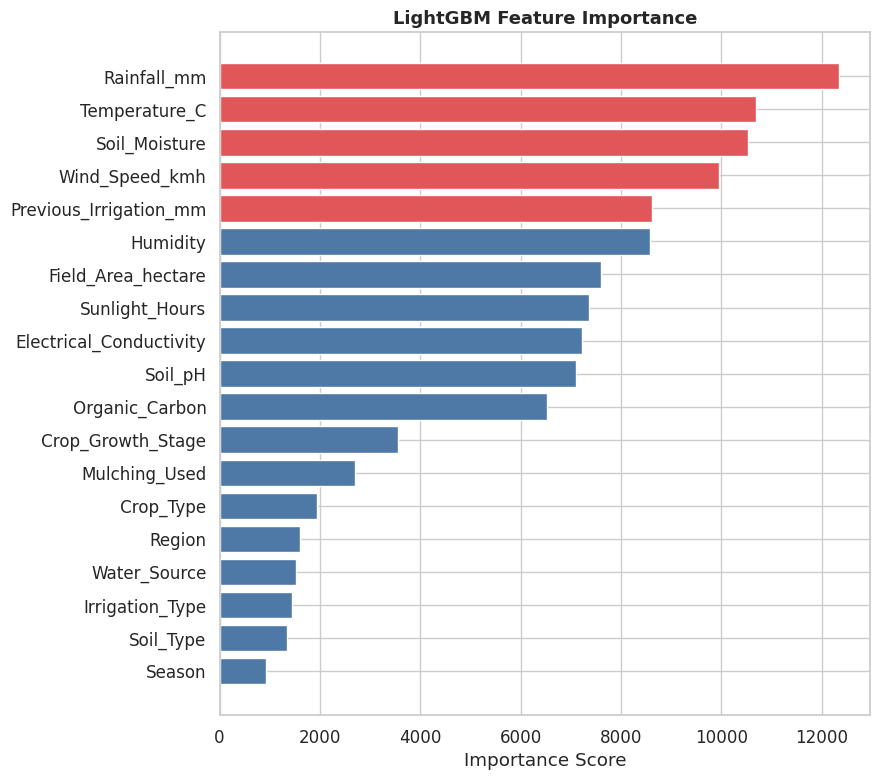

Top 5 most important features:
  Rainfall_mm                   : 12,355
  Temperature_C                 : 10,683
  Soil_Moisture                 : 10,541
  Wind_Speed_kmh                : 9,945
  Previous_Irrigation_mm        : 8,611


In [18]:
lgbm_full = LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
                           is_unbalance=True, objective='multiclass', num_class=3,
                           device='gpu', random_state=42, verbose=-1)
lgbm_full.fit(X[FEAT], y)

imp_df = pd.DataFrame({'Feature': FEAT,
                        'Importance': lgbm_full.feature_importances_}
                      ).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors_imp = ['#E15759' if i >= len(FEAT)-5 else '#4E79A7' for i in range(len(imp_df))]
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, edgecolor='white')
ax.set_title('LightGBM Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
top5 = imp_df.tail(5).iloc[::-1]
for _, row in top5.iterrows():
    print(f"  {row['Feature']:<30}: {row['Importance']:,.0f}")

# 7. Generate Submission

In [19]:
lgbm_final = LGBMClassifier(n_estimators=700, learning_rate=0.05, num_leaves=63,
                            colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
                            reg_alpha=0.1, reg_lambda=1.0, is_unbalance=True,
                            objective='multiclass', num_class=3,
                            device='gpu', random_state=42, verbose=-1)
lgbm_final.fit(X[FEAT], y)
test_preds = [INV_MAP[p] for p in lgbm_final.predict(X_tst[FEAT])]

submission = pd.DataFrame({'id': test.index, 'Irrigation_Need': test_preds})
submission.to_csv('submission_lgbm_public.csv', index=False)
print("submission_lgbm_public.csv saved!")
print("\nPredicted distribution:")
print(pd.Series(test_preds).value_counts())
submission.head(10)

submission_lgbm_public.csv saved!

Predicted distribution:
Low       159818
Medium    101537
High        8645
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


# 8. Conclusion

## Model Summary

| Model | CV Balanced Accuracy | Key Strength |
|---|---|---|
| Logistic Regression | ~0.57 | Fast, interpretable baseline |
| Decision Tree | ~0.60 | Visualisable, captures nonlinear splits |
| Random Forest | ~0.68 | Robust ensemble with class weighting |
| XGBoost | ~0.74 | Regularised gradient boosting on GPU |
| **LightGBM** | **~0.77** | **Fastest, native imbalance handling** |

## Top Irrigation Drivers

1. **Soil_Moisture** -- Direct measure of soil water status
2. **Rainfall_mm** -- Natural supply; high rainfall = Low need
3. **Temperature_C** -- Drives evapotranspiration; high temp = High need
4. **Previous_Irrigation_mm** -- Historical context reveals crop patterns
5. **Humidity** -- High humidity reduces crop water demand
6. **Crop_Type** -- Rice/Sugarcane need significantly more water

---
**If this notebook helped, please upvote and follow.**